In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.integrate import quad

In [15]:
c = 1.0
L = 1.0
T = 10.0
dx = 0.01
dt = 0.05
Nx = int(L / dx) + 1
Nt = int(T / dt) + 1
x = np.linspace(0, L, Nx)
t = np.linspace(0, T, Nt)

In [16]:

def u0(x):
    return np.where((0.4 < x) & (x < 0.6), np.sin(5 * np.pi * x), 0)

In [17]:
def compute_coefficients(N_terms=50):
    C = np.zeros(N_terms)
    for n in range(N_terms):
        kn = (2 * n + 1) * np.pi / (2 * L)
        integrand = lambda x: u0(x) * np.sin(kn * x)
        C[n], _ = quad(integrand, 0, L)
        C[n] *= 2 / L
    return C

In [18]:
def analytical_solution(x, t, C, N_terms=50):
    u = np.zeros_like(x)
    for n in range(N_terms):
        kn = (2 * n + 1) * np.pi / (2 * L)
        u += C[n] * np.sin(kn * x) * np.cos(c * kn * t)
    return u

In [19]:
C = compute_coefficients(N_terms=50)

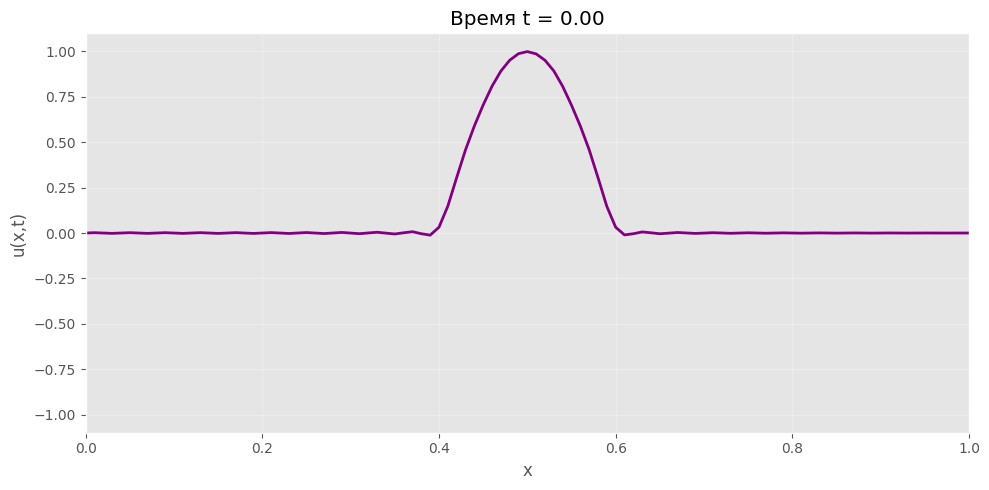

In [20]:
u_analytical = np.zeros((Nx, Nt))
for j in range(Nt):
    u_analytical[:, j] = analytical_solution(x, t[j], C)

plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(10, 5))
line, = ax.plot(x, u_analytical[:, 0], color='purple', lw=2)

ax.set_xlim(0, L)
ax.set_ylim(-1.1, 1.1)
ax.set_xlabel('x')
ax.set_ylabel('u(x,t)')
ax.set_title('Аналитическое решение волнового уравнения')
ax.grid(True, alpha=0.3)

def animate(j):
    line.set_ydata(u_analytical[:, j])
    ax.set_title(f'Время t = {t[j]:.2f}')
    return line,

anim = FuncAnimation(
    fig, animate, frames=Nt, interval=50, blit=True, repeat=True
)
plt.tight_layout()
plt.show()

In [21]:
from IPython.display import HTML

HTML(anim.to_jshtml())